In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
from tqdm import tqdm

In [2]:
%matplotlib inline

In [3]:
table = pd.read_table('x_0002_sed.out', delimiter='|').dropna()
unspliced_table = table[table.iloc[:, 8] == 64]
unspliced_table

/tmp/ipykernel_1183551/3223677935.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_table('x_0002_sed.out', delimiter='|').dropna()


,id,observation_id,format,size,freq_low,freq_high,location,deleted,coarse_channels,fch1,foff,nbits,tstart,tsamp,nsamples,nchans,nifs
1,4398816,421490.0,hdf5,52562451.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.370139,1.073742,279.0,65536.0,1.0
47,4398690,421590.0,hdf5,53401267.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.336528,1.073742,279.0,65536.0,1.0
48,4399034,421308.0,hdf5,51034626.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.908553,1.073742,279.0,65536.0,1.0
52,4398780,421560.0,hdf5,52180504.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.345023,1.073742,279.0,65536.0,1.0
53,4399026,421302.0,hdf5,51068334.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.927697,1.073742,279.0,65536.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421493,4398522,421500.0,hdf5,54081962.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.325301,1.073742,279.0,65536.0,1.0
421557,4399017,421288.0,hdf5,50948750.0,8626.466274,8813.966274,/datag/pipeline/AGBT23B_999_12/blc31_blp31/bl...,f,64.0,8813.964844,-0.002861,32.0,60287.904838,1.073742,279.0,65536.0,1.0
421566,4398578,421526.0,hdf5,53460399.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.329028,1.073742,279.0,65536.0,1.0
421648,4398634,421594.0,hdf5,53529568.0,11063.966274,11251.466274,/datag/pipeline/AGBT23B_999_14/blc50_blp10/bl...,f,64.0,11251.464844,-0.002861,32.0,60291.332755,1.073742,279.0,65536.0,1.0


In [4]:
locs = unspliced_table.iloc[:,6].tolist()
locs = [loc.replace(' ', '') for loc in locs]
locs

['/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_31980_HIP62637_0108.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29076_HIP53697_0099.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_78499_HIP96008_0012.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29810_HIP60074_0101.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_80153_HIP96085_0017.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_32302_IC3877_0109.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_30131_MESSIER100_0102.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_12/blc31_blp31/blc31_guppi_60287_81054_DDO210_0020.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_29490_MESSIER100_0100.rawspec.0002.h5',
 '/datag/pipeline/AGBT23B_999_14/blc50_blp10/blc50_guppi_60291_32627_HIP62860_0110.rawspec.

In [5]:
locs2 = [loc for loc in locs if '_3C' in loc]
locs2

['/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80655_3C48_0021.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80738_3C48_0022.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82882_3C48_0026.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_88/holding/blc16_guppi_58109_74832_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_88/holding/blc16_guppi_58109_74912_3C48_0009.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_84307_3C48_0028.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_82882_3C48_0026.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_97/holding/blc16_guppi_58117_80766_3C48_0034.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_97/holding/blc16_guppi_58117_80681_3C48_

In [6]:
locs3c48 = [loc for loc in locs2 if '3C48' in loc]
locs3c48

['/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80655_3C48_0021.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80738_3C48_0022.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82882_3C48_0026.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_88/holding/blc16_guppi_58109_74832_3C48_0008.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_88/holding/blc16_guppi_58109_74912_3C48_0009.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_84307_3C48_0028.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_82882_3C48_0026.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_97/holding/blc16_guppi_58117_80766_3C48_0034.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_97/holding/blc16_guppi_58117_80681_3C48_

In [7]:
len(locs3c48)

5500

# Selecting an ABACAD cadence

In [8]:
from itertools import groupby

def sort_key(l):
    return l.split('/')[3], l.split('_')[-4]

def get_target(l):
    return l.split('_')[-2]

def get_year(l):
    return int(l.split('/')[3][4:6])

def get_bank(l):
    return l.split('/')[5][3]

perley_targs = [
    '3C48', '3C123', '3C138', '3C144',
    '3C147', '3C196', '3C218', '3C274',
    '3C286', '3C295', '3C348', '3C353', 
    '3C380', '3C405', '3C444', '3C461'
]

groups = {
    target: {
        '_'.join(key): list(group)
        for key, group in groupby(sorted(loc, key=sort_key), key=sort_key)
    }
    for target, loc in groupby(sorted(locs, key=get_target), key=get_target)
    if target in perley_targs
}
groups

{'3C123': {'AGBT19A_999_08_58531': ['/datag/pipeline/AGBT19A_999_08/blp15/blc55_guppi_58531_13877_3C123_0007.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp15/blc55_guppi_58531_14017_3C123_0008.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp01/blc41_guppi_58531_13877_3C123_0007.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp01/blc41_guppi_58531_14017_3C123_0008.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp03/blc43_guppi_58531_13877_3C123_0007.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp03/blc43_guppi_58531_14017_3C123_0008.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp07/blc47_guppi_58531_13877_3C123_0007.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp07/blc47_guppi_58531_14017_3C123_0008.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp21/blc61_guppi_58531_13877_3C123_0007.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A_999_08/blp21/blc61_guppi_58531_14017_3C123_0008.gpuspec.0002.h5',
   '/datag/pipeline/AGBT19A

In [9]:
groups_all = {
    target: {
        '_'.join(key): list(group)
        for key, group in groupby(sorted(loc, key=sort_key), key=sort_key)
    }
    for target, loc in groupby(sorted(locs, key=get_target), key=get_target)
}
any('3C48' in l for l in list(groups_all.keys()))

True

In [10]:
good_targs = list(groups.keys())
good_targs

['3C123', '3C147', '3C196', '3C286', '3C295', '3C353', '3C48']

## Observation date distribution

In [11]:
xband_info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/spliced/all_xband_info.csv')
xband_info

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


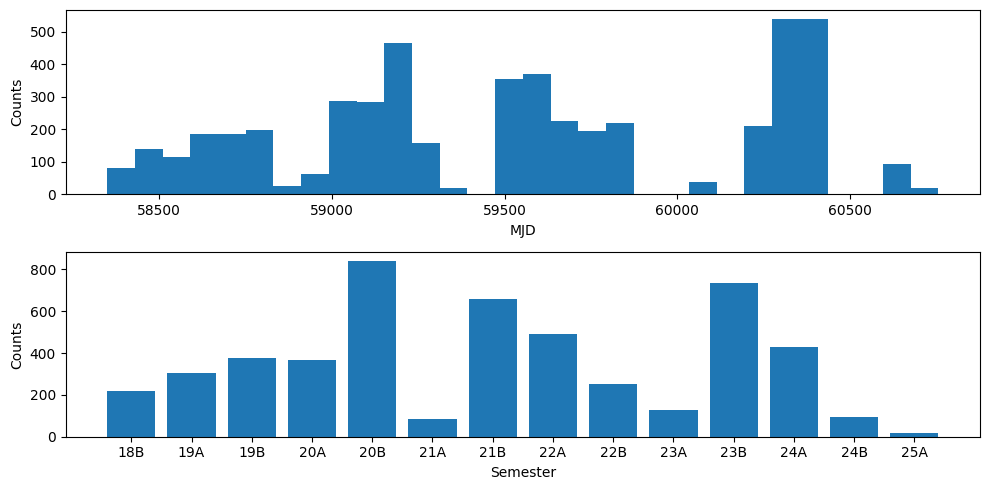

In [12]:
dates = [int(l.split('_')[0]) for l in xband_info['time']]
semesters = [l[4:7] for l in xband_info['epoch']]
labels, counts = np.unique(semesters, return_counts=True)

fig, axs = plt.subplots(2, 1, figsize=(10, 5))
axs[0].hist(dates, bins=30)
axs[0].set_xlabel('MJD')
axs[0].set_ylabel('Counts')

axs[1].bar(labels, counts)
axs[1].set_xlabel('Semester')
axs[1].set_ylabel('Counts')
plt.tight_layout()

### Aitoff projection w/ calibrators

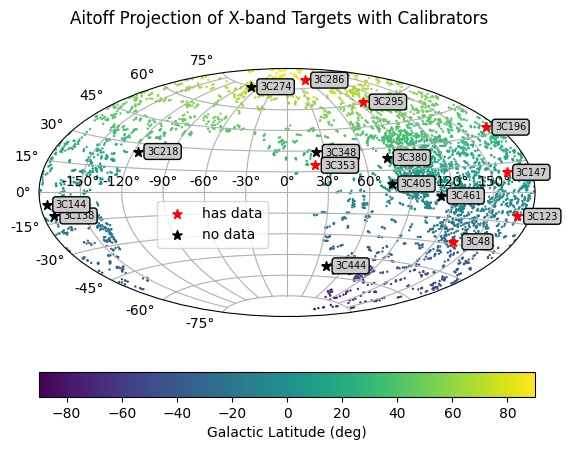

In [14]:
from astropy.coordinates import SkyCoord

gal = SkyCoord(xband_info['l'], xband_info['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=xband_info['b'], s=0.5, vmin=-90, vmax=90, zorder=1)
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Galactic Latitude (deg)')

cal_coords = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_coords_all.csv')
for target, l, b in zip(cal_coords['target'], cal_coords['l'], cal_coords['b']):
    cal_gal = SkyCoord(l, b, unit='deg', frame='galactic')
    color = 'r' if target in good_targs else 'k'
    label = 'has data' if target in good_targs else 'no data'
    ax.scatter(cal_gal.l.wrap_at('180d').radian, cal_gal.b.radian, s=50, c=color, marker='*', zorder=2, label=label)
    x, y = ax.transData.transform((np.radians(cal_gal.l.wrap_at('180d').deg), cal_gal.b.radian))
    x, y = ax.transAxes.inverted().transform((x, y))
    t = ax.text(x+0.05, y, target, fontsize=7, ha='center', va='center', transform=ax.transAxes)
    t.set_bbox(dict(boxstyle='round', fc='0.8'))

fig.suptitle('Aitoff Projection of X-band Targets with Calibrators')
handles, labels = ax.get_legend_handles_labels()
unique_handles, unique_labels = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

plt.legend(unique_handles, unique_labels, bbox_to_anchor=(0.35, 0.25))
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/mercator_with_calibrators.png', dpi=300)

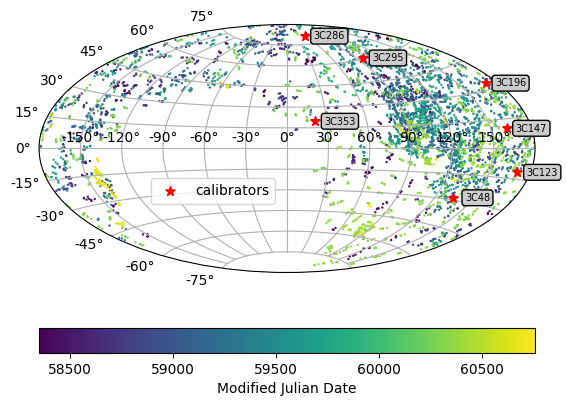

In [15]:
from astropy.coordinates import SkyCoord

def get_mjd(l):
    return int(l.split('_')[0])

def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

time_indices = np.argsort(xband_info['time'].apply(convert_to_seconds).to_numpy())
ls = xband_info['l'].to_numpy()[time_indices]
bs = xband_info['b'].to_numpy()[time_indices]
gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
days = xband_info['time'].apply(get_mjd)[time_indices]

gal = SkyCoord(ls, bs, unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)

scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=days, s=0.5, zorder=1)
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Modified Julian Date')

cal_coords = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_coords_all.csv')
for target, l, b in zip(cal_coords['target'], cal_coords['l'], cal_coords['b']):
    if target in good_targs:
        cal_gal = SkyCoord(l, b, unit='deg', frame='galactic')
        color = 'r'
        label = 'calibrators'
        ax.scatter(cal_gal.l.wrap_at('180d').radian, cal_gal.b.radian, s=50, c=color, marker='*', zorder=2, label=label)
        x, y = ax.transData.transform((np.radians(cal_gal.l.wrap_at('180d').deg), cal_gal.b.radian))
        x, y = ax.transAxes.inverted().transform((x, y))
        t = ax.text(x+0.05, y, target, fontsize=7, ha='center', va='center', transform=ax.transAxes)
        t.set_bbox(dict(boxstyle='round', fc='0.8'))

handles, labels = ax.get_legend_handles_labels()
unique_handles, unique_labels = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

plt.legend(unique_handles, unique_labels, bbox_to_anchor=(0.35, 0.25))
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/mercator_with_calibrators_aas.png', dpi=300)

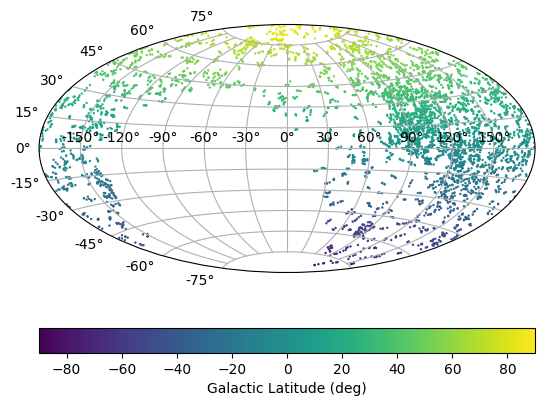

In [15]:
gal = SkyCoord(xband_info['l'], xband_info['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
scatter = plt.scatter(gal.l.wrap_at('180d').radian, gal.b.radian,
                      c=xband_info['b'], s=0.5, vmin=-90, vmax=90, zorder=1)
#cax = fig.add_axes([0.1, 0.1, 0.8, 0.03])
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal')
cbar.set_label('Galactic Latitude (deg)')

plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/mercator.png', dpi=300)

## Splicing

In [15]:
def get_time_seconds(l):
    return l.split('_')[-3]

def group_by_seconds(files):
    return groupby(sorted(files, key=get_time_seconds), key=get_time_seconds)

def group_by_cadence(files):
    seconds_group = {key: list(group) for key, group in group_by_seconds(files)}

    keys, values = list(seconds_group.keys()), list(seconds_group.values())

    cadences = []
    current_cadence = {keys[0]: values[0]}
    for i in range(len(keys)-1):
        diff = int(keys[i+1]) - int(keys[i])
        if 100 < diff < 140:
            current_cadence[keys[i+1]] = values[i+1]
        else:
            cadences.append(current_cadence)
            current_cadence = {keys[i+1]: values[i+1]}
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    if len(cadences) == 1:
        return cadences[0]
    return cadences

def group_by_target(epochs):
    return {
        epoch: group_by_cadence(files) for epoch, files in epochs.items()
        if len(group_by_cadence(files)) > 0
    }
# new_group = {
#     target: {
#         epoch: {key: list(group) for key, group in group_by_seconds(files)}
#         for epoch, files in epochs.items()
#         if len([k for k, _ in group_by_seconds(files)]) > 3
#     }
#     for target, epochs in groups.items()
# }
new_group = {
    target: group_by_target(epochs) for target, epochs in groups.items()
    if len(group_by_target(epochs)) > 0
}
new_group

{'3C123': {'AGBT20A_999_50_59033': [{'39600': ['/datag/pipeline/AGBT20A_999_50/blc00_blp00/blc00_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc15_blp15/blc15_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc20_blp20/blc20_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc11_blp11/blc11_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc06_blp06/blc06_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc10_blp10/blc10_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc07_blp07/blc07_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc04_blp04/blc04_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc14_blp14/blc14_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
     '/datag/pipeline/AGBT20A_999_50/blc

In [16]:
num_cadences = {target: sum(len(cadences) if isinstance(cadences, list) else 1 for cadences in epochs.values()) for target, epochs in new_group.items()}
num_cadences

{'3C123': 7, '3C147': 20, '3C196': 13, '3C286': 7, '3C295': 22, '3C48': 6}

### New sorting

In [17]:
def get_mjd_and_time_seconds(l):
    return '_'.join(l.split('_')[-4:-2])

def get_time_seconds(l):
    return l.split('_')[-3]

def group_by_mjd_and_time_seconds(files):
    return groupby(sorted(files, key=get_mjd_and_time_seconds), key=get_mjd_and_time_seconds)

In [18]:
sorted_by_mjd = sorted(locs2, key=get_mjd_and_time_seconds)
sorted_by_mjd

['/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc16_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc30_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc20_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc14_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc24_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc32_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc11_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc12_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc13_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc15_guppi_58100_82799_3C48_

In [19]:
def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    # Create dictionary to store cadences and corresponding files
    cadences_dict = {
        cadence[0]: {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadence[0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadence[1]],
        }
        for cadence in cadences
    }
    return cadences_dict

locs_sorted_by_target = {
    target: list(files)
    for target, files in groupby(sorted(locs, key=get_target), key=get_target)
    if target in perley_targs
}
locs_sorted_by_target

{'3C123': ['/datag/pipeline/AGBT20B_999_54/blc23_blp23/blc23_guppi_59213_82763_3C123_0008.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_54/blc23_blp23/blc23_guppi_59213_82893_3C123_0009.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc13_blp03/blc13_guppi_59196_27035_3C123_0094.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc13_blp03/blc13_guppi_59196_27176_3C123_0095.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc13_blp03/blc13_guppi_59196_27309_3C123_0096.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc32_blp22/blc32_guppi_59196_27035_3C123_0094.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc32_blp22/blc32_guppi_59196_27176_3C123_0095.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc32_blp22/blc32_guppi_59196_27309_3C123_0096.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_54/blc23_blp23/blc23_guppi_59213_82624_3C123_0007.rawspec.0002.h5',
  '/datag/pipeline/AGBT20B_999_48/blc23_blp13/blc23_guppi_59196_27035_3C123_0094.rawspec.0002.h5',
 

In [16]:
cadence_group = {
    target: group_by_cadence(files)
    for target, files in locs_sorted_by_target.items()
    if len(group_by_cadence(files))
}

cadence_group

{'3C123': {'59033_39600': {'ON': ['/datag/pipeline/AGBT20A_999_50/blc00_blp00/blc00_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc15_blp15/blc15_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc20_blp20/blc20_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc11_blp11/blc11_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc06_blp06/blc06_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc10_blp10/blc10_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc07_blp07/blc07_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc04_blp04/blc04_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc14_blp14/blc14_guppi_59033_39600_3C123_0009.rawspec.0002.h5',
    '/datag/pipeline/AGBT20A_999_50/blc05_blp05/blc05_guppi_5

In [17]:
num_cadences = {target: len(cadences) for target, cadences in cadence_group.items()}
num_cadences

{'3C123': 7, '3C147': 16, '3C196': 11, '3C286': 7, '3C295': 18, '3C48': 5}

### Splicing for real

In [20]:
from blimpy import Waterfall
from functools import partial
import gc
from multiprocessing import Pool
from tqdm.notebook import tqdm

path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'
rebinned_comb = np.load('/home/dataadmin/GBTData/SharedDataDirectory/rebinned_comb.npy')

def save_bank(items, name=''):
    bank, locs = items
    def despike(ys, cell_size=1024):
        for i in range(cell_size//2-1, len(ys), cell_size):
            ys[i] = np.mean([ys[i-1], ys[i+2]])
            ys[i+1] = np.mean([ys[i], ys[i+2]])
        return ys
    
    def rebin(xs, ys, cell_size=16):
        rebin_size=1024//cell_size
        rebinned_spec = []
        for i in range(len(ys)//rebin_size):
            average = np.mean(ys[i*rebin_size:i*rebin_size+rebin_size])
            rebinned_spec.append(average)

        rebinned_freq = []
        for i in range(len(xs)//rebin_size):
            average = np.mean(xs[i*rebin_size:i*rebin_size+rebin_size])
            rebinned_freq.append(average)
        return rebinned_freq, rebinned_spec
    
    def comb(spec):
        num_windows = len(spec) // 16
        reshaped_power = np.reshape(spec, (num_windows, 16))

        new_power = []
        for i in range(len(reshaped_power)):
            p = reshaped_power[i]
            c = rebinned_comb
            new_power.append(p / c)
        
        return np.concatenate(new_power)

    def process(loc):
        wf = Waterfall(loc)
        xs, ys = wf.grab_data()
        xs = xs[::-1]  # reverse the x-axis
        ys = ys[..., ::-1]  # reverse the y-axis
        ys_avg = np.mean(ys, axis=0)
        ys_despiked = despike(ys_avg)
        xs_rebin, ys_rebin = rebin(xs, ys_despiked)
        ys_combed = comb(ys_rebin)
        rebinned = np.array([xs_rebin, ys_combed])
        return rebinned

    specs = list(map(process, locs))
    bank_spec = np.concatenate(specs, axis=1)
    sort_indices = np.argsort(bank_spec[0])
    bank_spec = bank_spec[:, sort_indices]
    os.makedirs(os.path.join(path_to_save, bank, name.replace(name.split('/')[-1], '')), exist_ok=True)
    np.save(os.path.join(path_to_save, bank, name), bank_spec)

def splice_banks(name, locs):
    banks = {}
    for loc in locs:
        bank = loc.split('/')[4][-2]
        if bank not in banks:
            banks[bank] = []
        banks[bank].append(loc)
    banks_copy = {}
    for bank in banks.keys():
        new_bank = int(max(banks.keys(), key=int)) - int(bank)
        new_bank = str(new_bank)
        banks_copy[new_bank] = banks[bank]
    banks = banks_copy

    save_bank_partial = partial(save_bank, name=name)
    _ = list(map(save_bank_partial, banks.items()))
    gc.collect()
    return list(banks.keys())

def save_cadence(items, target=''):
    time, cadence_dict = items
    name_on = f'{target}/{time}/ON.npy'
    banks_on = splice_banks(name_on, cadence_dict['ON'])
    name_off = f'{target}/{time}/OFF.npy'
    banks_off = splice_banks(name_off, cadence_dict['OFF'])
    banks = set(banks_on).intersection(set(banks_off))

    for bank in banks:
        bank_path = os.path.join(path_to_save, bank)
        spec_on = np.load(os.path.join(bank_path, name_on))
        spec_off = np.load(os.path.join(bank_path, name_off))
        spec_diff = np.array([spec_on[0], (spec_on[1] - spec_off[1]) / spec_off[1]])
        np.save(os.path.join(bank_path, f'{target}/{time}/ON_OFF.npy'), spec_diff)

def save_target(items):
    target, target_dict = items
    save_cadence_partial = partial(save_cadence, target=target)
    _ = list(tqdm(map(save_cadence_partial, target_dict.items()), total=len(target_dict), desc=f'Saving target {target}'))

_ = list(map(save_target, cadence_group.items()))

Saving target 3C123:   0%|          | 0/7 [00:00<?, ?it/s]

Saving target 3C147:   0%|          | 0/16 [00:00<?, ?it/s]

Saving target 3C196:   0%|          | 0/11 [00:00<?, ?it/s]

Saving target 3C286:   0%|          | 0/7 [00:00<?, ?it/s]

Saving target 3C295:   0%|          | 0/18 [00:00<?, ?it/s]

Saving target 3C48:   0%|          | 0/5 [00:00<?, ?it/s]

In [33]:
cadence_group['3C295']['59348_41294']

{'ON': ['/datag/pipeline/AGBT21A_996_36/blc45/blc45_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc40/blc40_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc46/blc46_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc44/blc44_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc57/blc57_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc66/blc66_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc55/blc55_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc41/blc41_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc67/blc67_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc54/blc54_guppi_59348_41294_3C295_0115.rawspec.0002.h5',
  '/datag/pipeline/AGBT21A_996_36/blc62/blc62_guppi_59348_41294_

# Calculating SEFD

In [19]:
perley_coeffs = {
    '3C123': [1.8017, -0.7884, -0.1035, -0.0248, 0.0090],
    '3C147': [1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289],
    '3C196': [1.2872, -0.8530, -0.1534, -0.0200, 0.0201],
    '3C286': [1.2481, -0.4507, -0.1798, 0.0357],
    '3C295': [1.4701, -0.7658, -0.2780, -0.0347, 0.0399],
    '3C48': [1.3253, -0.7553, -0.1914, 0.0498]
}
def flux_jy(freqs, target):
    model = np.poly1d(perley_coeffs[target][::-1])
    return 10**model(np.log10(freqs/1e3)) # convert MHz to GHz

k = 1.38e-23  # Boltzmann constant in J/K
JY_PER_J = 1e26 # Jy per Joule

def calculate_sefd(spec, target, eta=0.7, r=50, Tsky=2.728):
    freqs, powers = spec
    s_cal = flux_jy(freqs, target)
    a_eff = eta * np.pi * r**2
    sefd = s_cal / powers - 2 * k * JY_PER_J * Tsky / a_eff
    return np.array([freqs, sefd])

In [28]:
min_freq = 7689.057827
path_to_save = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'

for bank in range(4):
    calibration_dir = os.path.join(path_to_save, str(bank))
    
    for target in os.listdir(calibration_dir):
        for cadence in os.listdir(os.path.join(calibration_dir, target)):
            path = os.path.join(calibration_dir, target, cadence)
            try:
                spec = np.load(os.path.join(path, 'ON_OFF.npy'))
            except FileNotFoundError:
                print(f'ON_OFF.npy not found for {path}, skipping SEFD calculation')
                continue
            sefd = calculate_sefd(spec, target)
            sefd = sefd[:, np.argmin(np.abs(sefd[0] - min_freq)):]
            #print(sefd)
            np.save(os.path.join(path, 'SEFD.npy'), sefd)

# Plots

## Test

Text(0.5, 1.0, '3C123/60277_36476')

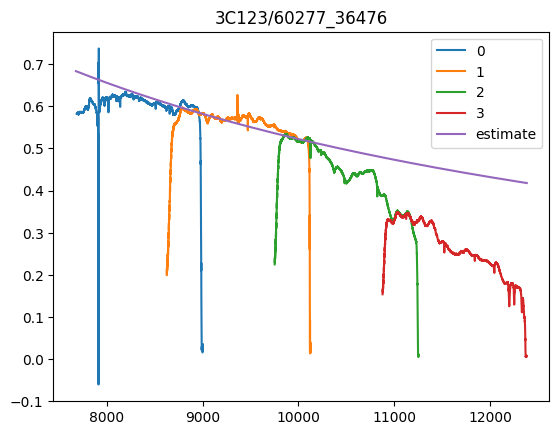

In [22]:
import random
#cadence = f'3C48/{random.choice(list(cadence_group["3C48"].keys()))}'
cadence = '3C123/60277_36476'
for bank in range(4):
    plt.plot(*np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/{bank}/{cadence}/ON_OFF.npy'), label=str(bank))
# Overlay flux model
xs = np.linspace(7680, 12380, 1000)
plt.plot(xs, flux_jy(xs, '3C123')/15, label='estimate')
plt.legend()
plt.title(cadence)

In [9]:
np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/{bank}/{cadence}/ON_OFF.npy')[0][-1]

12376.3747215271

Text(0, 0.5, 'Number of Cadences')

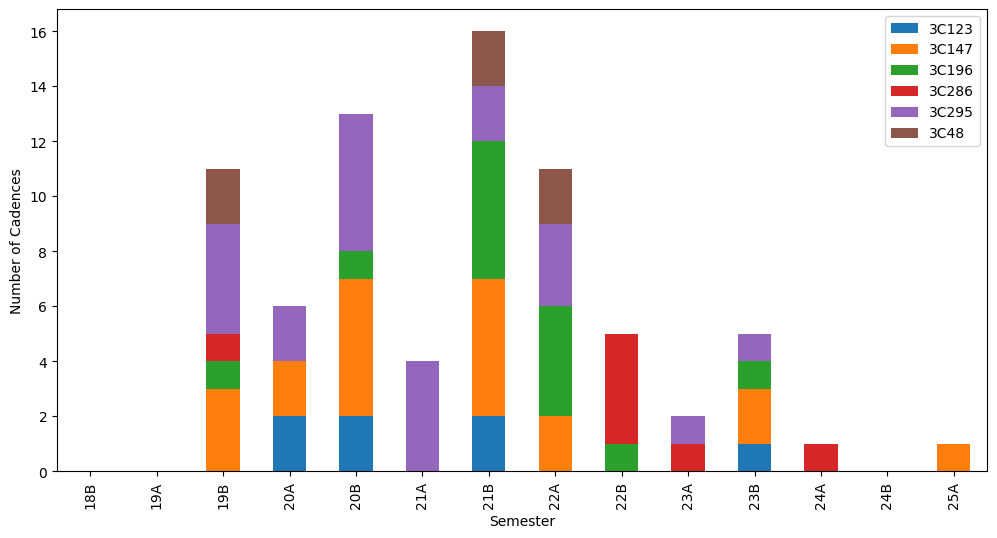

In [61]:
# Semester plot of the cadences
all_semesters = ['18B', '19A', '19B', '20A',
                 '20B', '21A', '21B', '22A',
                 '22B', '23A', '23B', '24A',
                 '24B', '25A']
# For each target, get the number of cadences in each semester
semester_counts = {
    target: [
        [cadence['ON'][0].split('/')[3][4:7] for cadence in cadences.values()].count(sem)
        for sem in all_semesters
    ]
    for target, cadences in cadence_group.items()
}
# Turn into a DataFrame for easier plotting
semester_df = pd.DataFrame(semester_counts, index=all_semesters)
semester_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Semester')
plt.ylabel('Number of Cadences')

In [9]:
np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/0/3C123/59033_39600/SEFD.npy')

array([[[7689.057827  , 7689.24093246, 7689.42403793, ...,
         9001.00851059, 9001.19161606, 9001.37472153]],

       [[  11.65185641,   11.52685087,   11.50887243, ...,
          262.75058559,  269.67840351,  275.76581522]]])

[[7689.057827   7689.24093246 7689.42403793 ... 9001.00851059
  9001.19161606 9001.37472153]
 [  18.56928721   18.52338915   18.55046772 ...  245.99737163
   257.77232556  256.69105257]]
[[ 8626.557827    8626.74093246  8626.92403793 ... 10126.00851059
  10126.19161606 10126.37472153]
 [   48.34949696    46.27526656    45.98366082 ...   176.94341987
    204.48862877   200.78695314]]
[[ 9751.557827    9751.74093246  9751.92403793 ... 11251.00851059
  11251.19161606 11251.37472153]
 [   41.13852837    39.63627479    38.96334785 ...   486.05641278
    500.05014749   492.21753002]]
[[10876.557827   10876.74093246 10876.92403793 ... 12376.00851059
  12376.19161606 12376.37472153]
 [   37.51641973    36.51331967    36.149583   ...  1305.78205872
   1350.45411041  1521.89121343]]


Text(0.5, 1.0, '3C147/60325_78863')

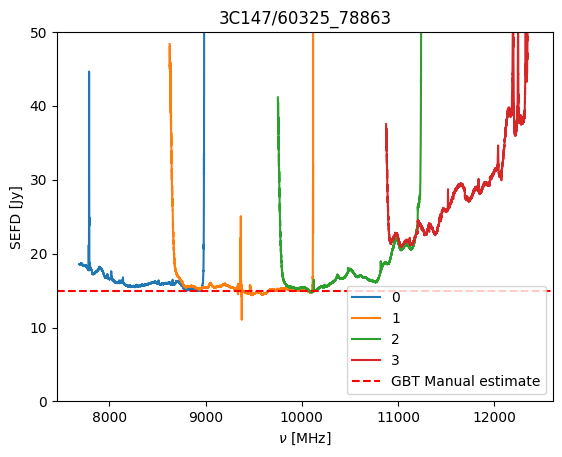

In [23]:
cadence = '3C147/60325_78863'
for bank in range(4):
    spec = np.load(f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/{bank}/{cadence}/SEFD.npy')
    print(spec)
    plt.plot(*spec, label=str(bank))
plt.axhline(15, color='r', linestyle='--', label='GBT Manual estimate')
plt.legend()
plt.ylim(0, 50)
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('SEFD [Jy]')
plt.title(cadence)

In [20]:
os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/0/')

['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']

SEFD shape mismatch for 0/3C196/59525_56816, skipping
(2, 6144)
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(2, 4096)
SEFD shape mismatch for 1/3C48/59572_22577, skipping
(2, 7168)
No data for 3C48 in bank 3, skipping


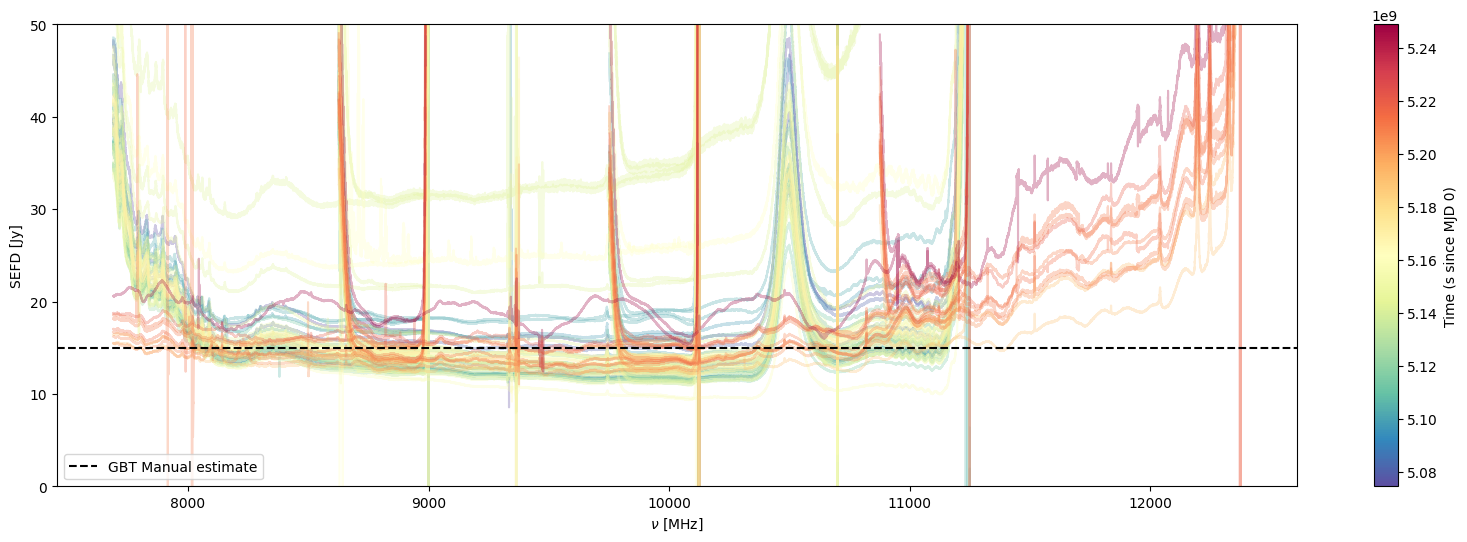

In [19]:
# Plot SEFDs over time
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'

all_sefd = []
times = []

for target in targets:
    banks = [0, 1, 2, 3]
    for bank in banks:
        shape = 7168 if bank == 0 else 8192
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                if sefd.shape[1] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                all_sefd.append(sefd)
                times.append(convert_to_seconds(cadence))
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
        
# Sort by times
combined = sorted(zip(times, all_sefd), key=lambda x: x[0])
all_sefd = [sefd for _, sefd in combined]

import matplotlib as mpl
cmap = mpl.colormaps['Spectral_r']
norm = mpl.colors.Normalize(vmin=min(times), vmax=max(times))
# Plot
fig, ax = plt.subplots(figsize=(20, 6))
for time, sefd in combined:
    ax.plot(sefd[0], sefd[1], alpha=0.3, color=cmap(norm(time)))
plt.axhline(15, color='k', linestyle='--', label='GBT Manual estimate')
plt.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Time (s since MJD 0)')
plt.ylim(0, 50)
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('SEFD [Jy]')
plt.legend()

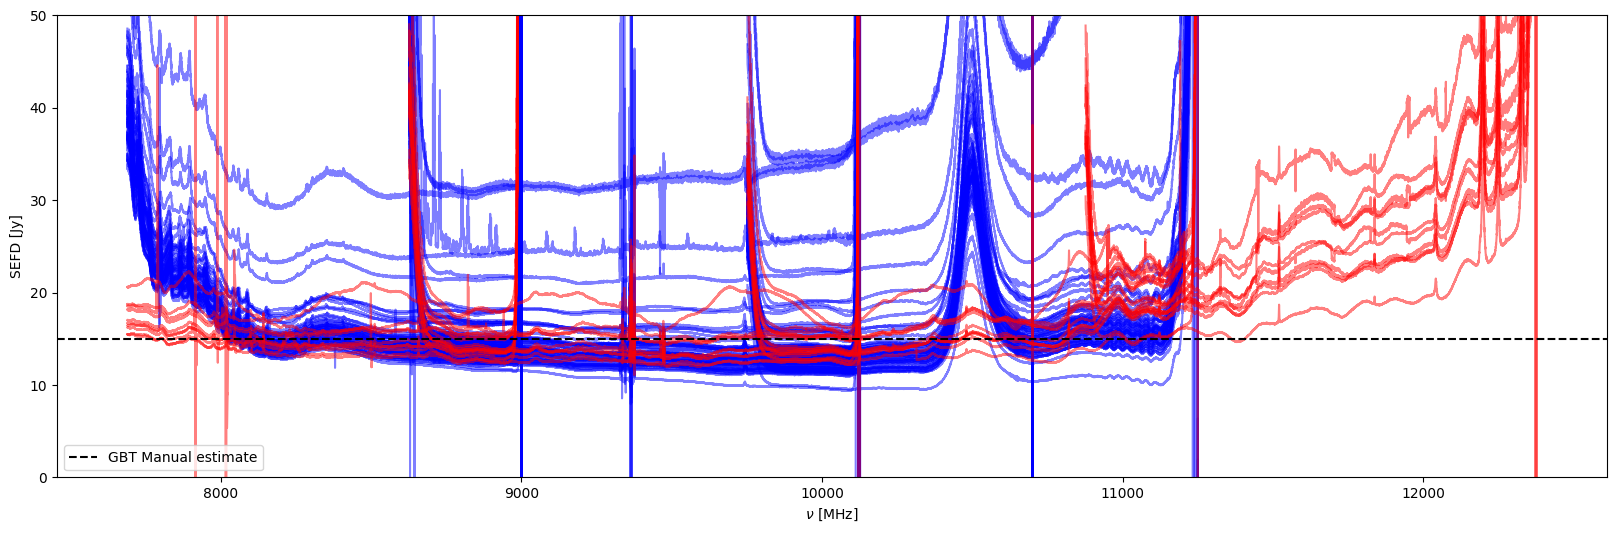

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(20, 6))
for time, sefd in combined:
    ax.plot(sefd[0], sefd[1], alpha=0.5, color='red' if time > 5.18e9 else 'blue')
plt.axhline(15, color='k', linestyle='--', label='GBT Manual estimate')
plt.ylim(0, 50)
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('SEFD [Jy]')
plt.legend()

Text(0.5, 1.0, 'Time Distribution of X-band Target Observations')

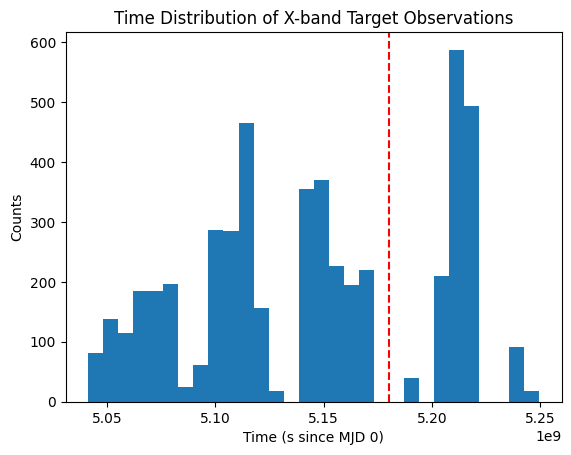

In [21]:
# Histogram of target times
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/spliced/all_xband_info.csv')
times = [convert_to_seconds(l) for l in info['time']]
plt.hist(times, bins=30)
plt.axvline(5.18e9, color='r', linestyle='--')
plt.xlabel('Time (s since MJD 0)')
plt.ylabel('Counts')
plt.title('Time Distribution of X-band Target Observations')

63 63 63


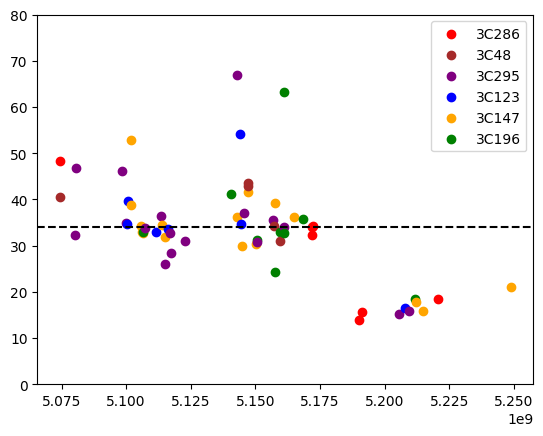

In [30]:
# Change in 10.5 GHz peak over time
freq = 10500
all_sefd = []
times = []
target_names = []
colors = {
    '3C123': 'blue',
    '3C147': 'orange',
    '3C196': 'green',
    '3C286': 'red',
    '3C295': 'purple',
    '3C48': 'brown'
}
bank = 2

for target in targets:
    shape = 7168 if bank == 0 else 8192
    calibration_dir = os.path.join(calibration_path, str(bank), target)
    if not os.path.exists(calibration_dir):
        print(f'No data for {target} in bank {bank}, skipping')
        continue
    for cadence in os.listdir(calibration_dir):
        target_names.append(target)
        path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
        try:
            sefd = np.load(path)
            if sefd.shape[1] != shape:
                print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                print(sefd.shape)
                continue
            all_sefd.append(sefd)
            times.append(convert_to_seconds(cadence))
        except FileNotFoundError:
            print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
            continue

peak_values = [sefd[1][np.argmin(np.abs(sefd[0] - freq))] for sefd in all_sefd]
print(len(peak_values), len(times), len(target_names))

combined = sorted(zip(times, peak_values, target_names), key=lambda x: x[0])

fig, ax = plt.subplots()
for time, peak, target in list(combined):
    ax.scatter(time, peak, c=colors[target], label=target)
ax.axhline(np.median(peak_values), linestyle='--', color='k')
ax.set_ylim(0,80)

handles, labels = ax.get_legend_handles_labels()
unique_handles, unique_labels = [], []
for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_handles.append(handle)
        unique_labels.append(label)

ax.legend(unique_handles, unique_labels)


In [26]:
np.sum(np.array(times) > 5.18e9)

1438

In [30]:
5.18e9/86400

59953.7037037037

SEFD.npy not found for 1/3C147/59468_22454, skipping
SEFD shape mismatch for 0/3C196/59525_56816, skipping
(6144,)
SEFD shape mismatch for 1/3C196/59482_66206, skipping
(7168,)
SEFD shape mismatch for 0/3C295/58705_21062, skipping
(1,)
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(3072,)
SEFD shape mismatch for 1/3C295/58705_21062, skipping
(1,)
SEFD shape mismatch for 1/3C295/59328_42471, skipping
(7168,)
SEFD shape mismatch for 2/3C295/58705_21062, skipping
(1,)
SEFD shape mismatch for 1/3C48/59572_22577, skipping
(7168,)
No data for 3C48 in bank 3, skipping


Text(0, 0.5, 'SEFD [Jy]')

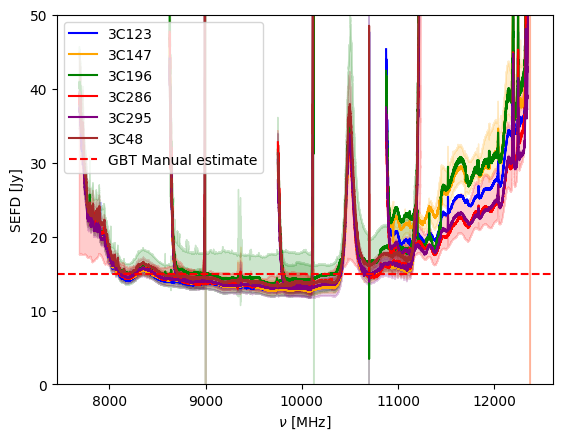

In [46]:
# Average SEFD of all targets
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'black', 'teal', 'navy', 'maroon']
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48'] #os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/0/')
for target, color in zip(targets, colors):
    for bank in range(4):
        shape = 7168 if bank == 0 else 8192
        calibration_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/{bank}/{target}'
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        all_sefd = []
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)[1]
                if sefd.shape[0] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                all_sefd.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
        median = np.median(all_sefd, axis=0)
        q1 = np.percentile(all_sefd, 25, axis=0)
        q3 = np.percentile(all_sefd, 75, axis=0)
        label = target if bank == 0 else None
        plt.plot(np.load(path)[0], median, label=label, color=color)
        plt.fill_between(np.load(path)[0], q1, q3, color=color, alpha=0.2)
        # for sefd in all_sefd:
        #     plt.plot(np.load(path)[0], sefd, color=color, alpha=0.1)
plt.axhline(15, color='r', linestyle='--', label='GBT Manual estimate')
plt.legend()
plt.ylim(0,50)
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('SEFD [Jy]')

## Redshifts

SEFD shape mismatch for 0/3C295/58705_21062, skipping
SEFD shape mismatch for 0/3C295/59348_41294, skipping
SEFD shape mismatch for 0/3C196/59525_56816, skipping


AttributeError: 'Axes' object has no attribute 'xlabel'

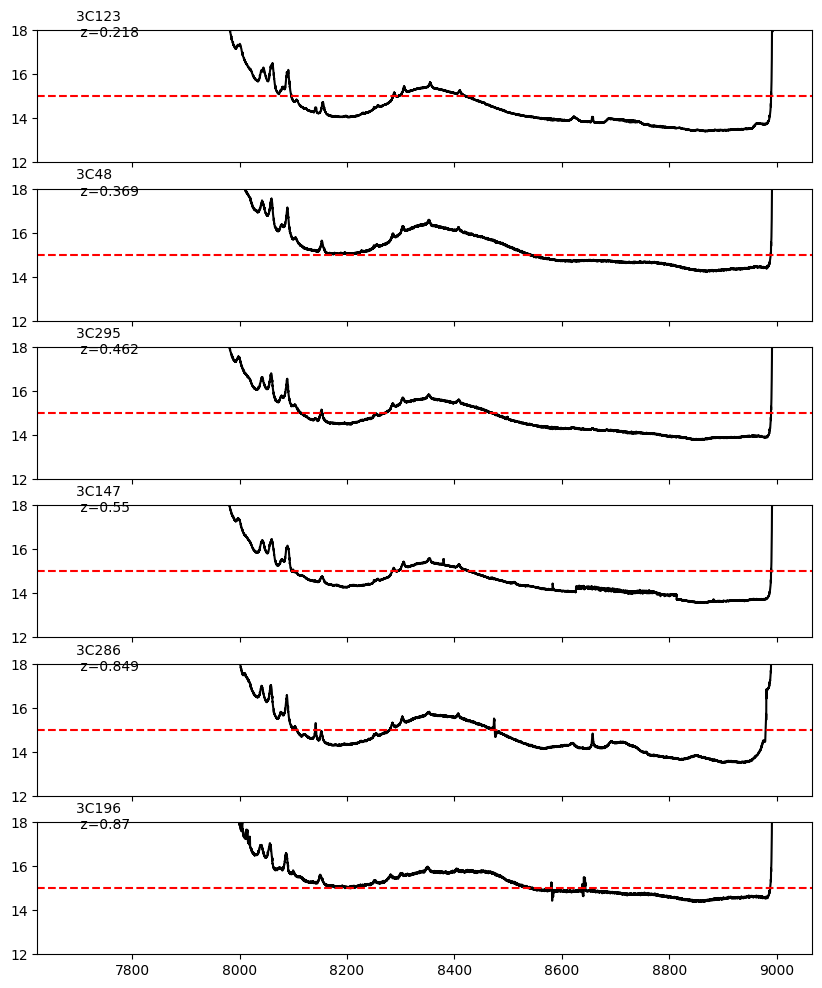

In [16]:
#source: SIMBAD
redshifts = {
    '3C123': 0.218,
    '3C147': 0.55,
    '3C196': 0.87,
    '3C286': 0.849,
    '3C295': 0.462,
    '3C48': 0.369
}

targets = sorted(os.listdir('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/0/'), key=lambda t: redshifts.get(t, 0))
fig, axs = plt.subplots(len(targets), 1, figsize=(10, 2*len(targets)), sharex=True, sharey=True)

for ax, target in zip(axs, targets):
    for bank in range(1):
        shape = 7168 if bank == 0 else 8192
        calibration_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra/{bank}/{target}'
        all_sefd = []
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)[1]
                if sefd.shape[0] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    continue
                all_sefd.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
        median = np.median(all_sefd, axis=0)
        ax.plot(np.load(path)[0], median, color='k')
    ax.text(0.05, 0.95, f'{target} \n z={redshifts.get(target, 0)}', transform=ax.transAxes)
    ax.axhline(15, color='r', linestyle='--', label='GBT Manual estimate')
    ax.set_ylim(12, 18)

ax.xlabel('$\\nu$ [MHz]')
ax.ylabel('SEFD [Jy]')

# Saving the median SEFDs

In [27]:
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'
med_sefd_path = '/home/dataadmin/GBTData/SharedDataDirectory/median_sefds/'

banks = [0, 1, 2]
for bank in banks:
    os.makedirs(os.path.join(med_sefd_path, str(bank)), exist_ok=True)
    pre22B = []
    post22B = []
    shape = 7168 if bank == 0 else 8192
    for target in targets:
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(path)
                if sefd.shape[1] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                time = convert_to_seconds(cadence)
                if time < 5.18e9:
                    pre22B.append(sefd)
                else:
                    post22B.append(sefd)
            except FileNotFoundError:
                print(f'SEFD.npy not found for {bank}/{target}/{cadence}, skipping')
                continue
    if pre22B:
        pre22B_median = np.median(pre22B, axis=0)
        pre22B_16 = np.percentile(pre22B, 16, axis=0)
        pre22B_84 = np.percentile(pre22B, 84, axis=0)
        np.save(os.path.join(med_sefd_path, str(bank), 'pre22B_median.npy'), pre22B_median)
        np.save(os.path.join(med_sefd_path, str(bank), 'pre22B_16th.npy'), pre22B_16)
        np.save(os.path.join(med_sefd_path, str(bank), 'pre22B_84th.npy'), pre22B_84)
    if post22B:
        post22B_median = np.median(post22B, axis=0)
        post22B_16 = np.percentile(post22B, 16, axis=0)
        post22B_84 = np.percentile(post22B, 84, axis=0)
        np.save(os.path.join(med_sefd_path, str(bank), 'post22B_median.npy'), post22B_median)
        np.save(os.path.join(med_sefd_path, str(bank), 'post22B_16th.npy'), post22B_16)
        np.save(os.path.join(med_sefd_path, str(bank), 'post22B_84th.npy'), post22B_84)

SEFD shape mismatch for 0/3C196/59525_56816, skipping
(2, 6144)
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(2, 4096)
SEFD shape mismatch for 1/3C48/59572_22577, skipping
(2, 7168)


[[7689.057827   7689.24093246 7689.42403793 ... 9001.00851059
  9001.19161606 9001.37472153]
 [  15.81792202   15.82725874   15.80727452 ...  238.80766707
   241.60307965  246.49549995]]
[[ 8626.557827    8626.74093246  8626.92403793 ... 10126.00851059
  10126.19161606 10126.37472153]
 [   38.22172711    36.44947583    35.93907556 ...   150.00133316
    200.5626471    203.10867691]]
[[ 9751.557827    9751.74093246  9751.92403793 ... 11251.00851059
  11251.19161606 11251.37472153]
 [   31.69843175    30.52988945    30.16738126 ...   538.13517501
    528.80380163   527.1146739 ]]


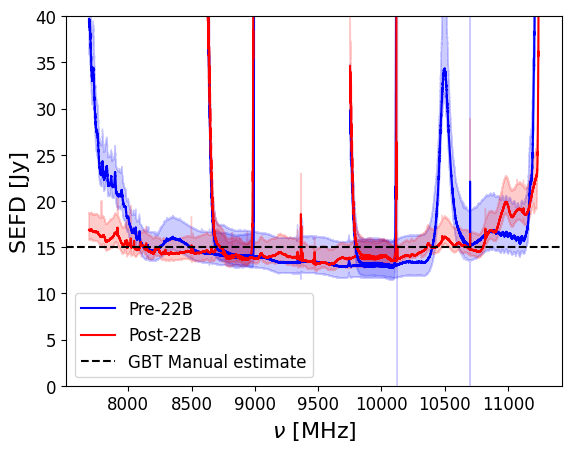

In [29]:
# Plot the median SEFDs
plt.rcParams.update({'font.size': 12})

for bank in banks:
    path = os.path.join(med_sefd_path, str(bank))
    if os.path.exists(path):
        pre22B_median = np.load(os.path.join(path, 'pre22B_median.npy'))
        pre22B_16 = np.load(os.path.join(path, 'pre22B_16th.npy'))
        pre22B_84 = np.load(os.path.join(path, 'pre22B_84th.npy'))
        plt.plot(pre22B_median[0], pre22B_median[1], color='blue', label='Pre-22B' if bank == 0 else None)
        plt.fill_between(pre22B_median[0], pre22B_16[1], pre22B_84[1], color='blue', alpha=0.2)
        post22B_median = np.load(os.path.join(path, 'post22B_median.npy'))
        post22B_16 = np.load(os.path.join(path, 'post22B_16th.npy'))
        post22B_84 = np.load(os.path.join(path, 'post22B_84th.npy'))
        print(post22B_16)
        plt.plot(post22B_median[0], post22B_median[1], color='red', label='Post-22B' if bank == 0 else None)
        plt.fill_between(post22B_median[0], post22B_16[1], post22B_84[1], color='red', alpha=0.2)

plt.ylim(0,40)
plt.axhline(15, color='k', linestyle='--', label='GBT Manual estimate')
plt.legend()
plt.xlabel('$\\nu$ [MHz]', fontsize=16)
plt.ylabel('SEFD [Jy]', fontsize=16)
plt.savefig('/home/dataadmin/GBTData/SharedDataDirectory/median_sefds_aas.png', dpi=300, bbox_inches='tight')

(array([1.000e+00, 1.000e+00, 0.000e+00, 3.000e+00, 1.000e+01, 2.800e+01,
        1.700e+01, 7.000e+01, 1.527e+03, 5.964e+03, 5.680e+02, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([0.7       , 0.72068966, 0.74137931, 0.76206897, 0.78275862,
        0.80344828, 0.82413793, 0.84482759, 0.86551724, 0.8862069 ,
        0.90689655, 0.92758621, 0.94827586, 0.96896552, 0.98965517,
        1.01034483, 1.03103448, 1.05172414, 1.07241379, 1.09310345,
        1.1137931 , 1.13448276, 1.15517241, 1.17586207, 1.19655172,
        1.21724138, 1.23793103, 1.25862069, 1.27931034, 1.3       ]),
 <BarContainer object of 29 artists>)

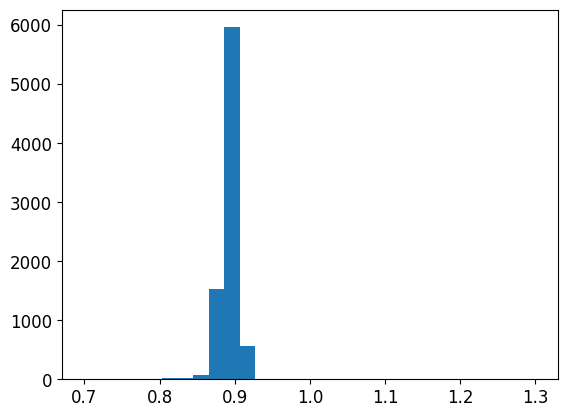

In [35]:
plt.hist(pre22B_16[1] / pre22B_median[1], bins=np.linspace(0.7, 1.3, 30))

# Gains

In [20]:
def sefd_to_tsys(sefd, eta=0.7, r=50):
    a_eff = eta * np.pi * r**2
    tsys = sefd * a_eff / (2 * k * JY_PER_J)
    return tsys

def calculate_gain(powers, sefd):
    tsys = sefd_to_tsys(sefd)
    return powers / tsys

Error processing 0/3C147/59776_79130: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
Error processing 0/3C147/60749_64920: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
SEFD shape mismatch for 0/3C196/59525_56816, skipping
(2, 6144)
Error processing 0/3C196/59715_10535: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
Error processing 0/3C196/59819_75836: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
Error processing 0/3C286/58731_02630: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
Error processing 0/3C286/60068_30822: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
Error processing 0/3C286/60083_25833: operands could not be broadcast together with shapes (8192,) (7168,) , skipping
SEFD shape mismatch for 0/3C295/59348_41294, skipping
(2, 4096)
Error processing 0/3C48/59715_34608: operands 

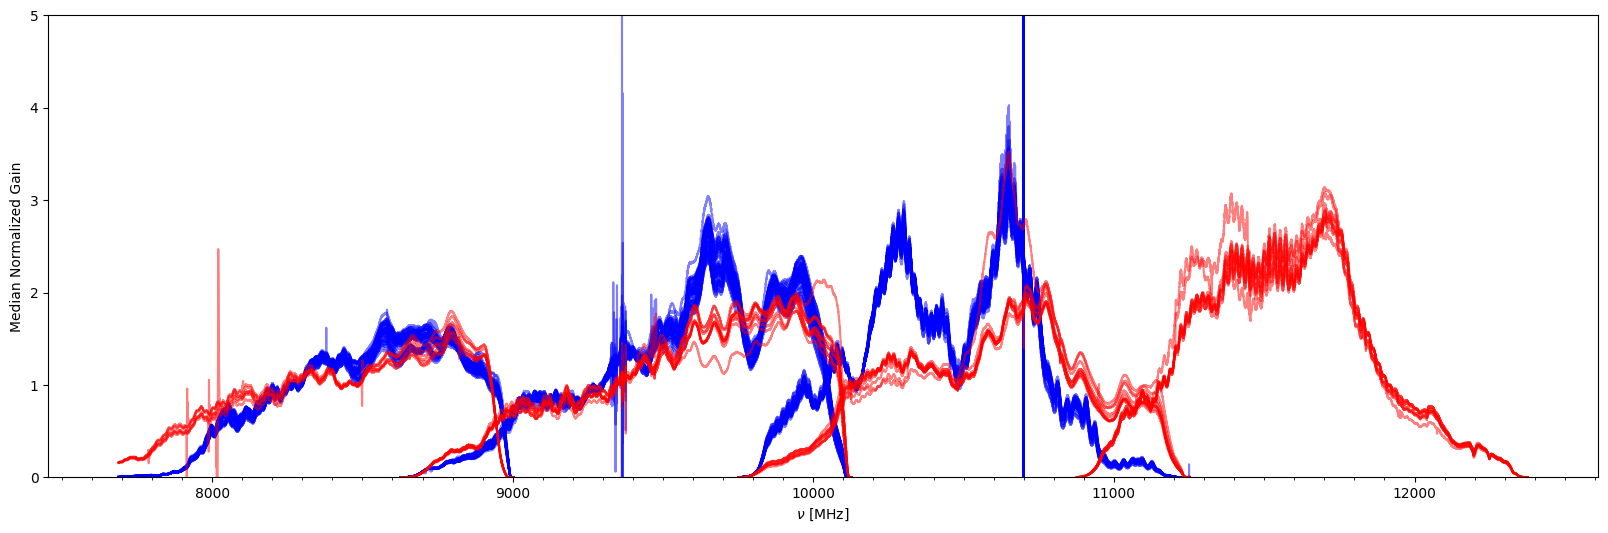

In [21]:
# Plot gains over time
targets = ['3C123', '3C147', '3C196', '3C286', '3C295', '3C48']
calibration_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/'

all_gains = []
times = []

for target in targets:
    banks = [0, 1, 2, 3]
    for bank in banks:
        shape = 7168 if bank == 0 else 8192
        calibration_dir = os.path.join(calibration_path, str(bank), target)
        if not os.path.exists(calibration_dir):
            print(f'No data for {target} in bank {bank}, skipping')
            continue
        for cadence in os.listdir(calibration_dir):
            off_path = os.path.join(calibration_dir, cadence, 'OFF.npy')
            sefd_path = os.path.join(calibration_dir, cadence, 'SEFD.npy')
            try:
                sefd = np.load(sefd_path)
                if sefd.shape[1] != shape:
                    print(f'SEFD shape mismatch for {bank}/{target}/{cadence}, skipping')
                    print(sefd.shape)
                    continue
                off = np.load(off_path)
                gain = calculate_gain(off[1], sefd[1])
                norm_gain = gain / np.median(gain)
                all_gains.append(np.array([sefd[0], norm_gain]))
                times.append(convert_to_seconds(cadence))
            except Exception as e:
                print(f'Error processing {bank}/{target}/{cadence}: {e}, skipping')
                continue
        
# Sort by times
combined = sorted(zip(times, all_gains), key=lambda x: x[0])

fig, ax = plt.subplots(figsize=(20, 6))
for time, gain in combined:
    ax.plot(gain[0], gain[1], alpha=0.5, color='red' if time > 5.18e9 else 'blue')
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('Median Normalized Gain')
plt.ylim(0, 5)

import matplotlib.ticker as tck
ax.xaxis.set_minor_locator(tck.MultipleLocator(100))

In [22]:
sum([convert_to_seconds(l) > 5.18e9 for l in xband_info['time']])

1438

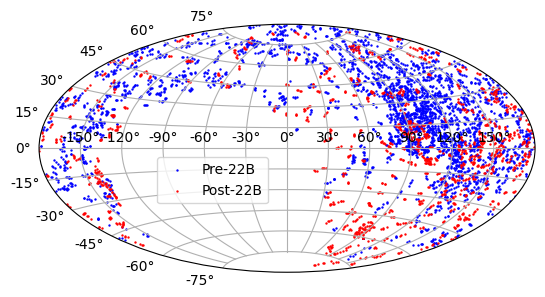

In [23]:
from astropy.coordinates import SkyCoord

pre22B_info = xband_info[xband_info['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9)]
post22B_info = xband_info[xband_info['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9)]
galpre = SkyCoord(pre22B_info['l'], pre22B_info['b'], unit='deg', frame='galactic')
galpost = SkyCoord(post22B_info['l'], post22B_info['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
pre_sc = plt.scatter(galpre.l.wrap_at('180d').radian, galpre.b.radian,
                      c='blue', s=0.5, zorder=1, label='Pre-22B')
post_sc = plt.scatter(galpost.l.wrap_at('180d').radian, galpost.b.radian,
                      c='red', s=0.5, zorder=1, label='Post-22B')
plt.legend(bbox_to_anchor=(0.35, 0.25))

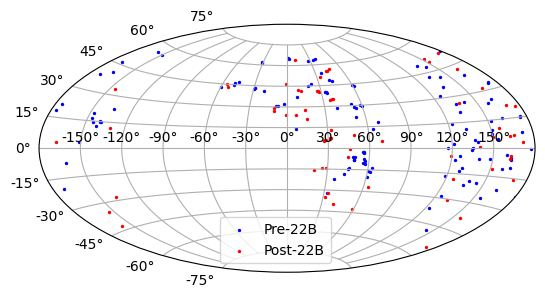

In [24]:
# Select 200 target sample
targets = []
target_dir ='/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/'
with open(os.path.join(target_dir, 'snr_targets_200.txt'), 'r') as file:
    for line in file:
        targets.append(line.strip())

xband_info_sample = xband_info[xband_info['source'].isin(targets)]
pre22B_info_sample = xband_info_sample[xband_info_sample['time'].apply(lambda t: convert_to_seconds(t) < 5.18e9)]
post22B_info_sample = xband_info_sample[xband_info_sample['time'].apply(lambda t: convert_to_seconds(t) >= 5.18e9)]
galpre = SkyCoord(pre22B_info_sample['l'], pre22B_info_sample['b'], unit='deg', frame='galactic')
galpost = SkyCoord(post22B_info_sample['l'], post22B_info_sample['b'], unit='deg', frame='galactic')
fig = plt.figure()
ax = fig.add_subplot(111, projection='aitoff')
ax.grid(zorder=0)
pre_sc = plt.scatter(galpre.l.wrap_at('180d').radian, galpre.b.radian,
                      c='blue', s=2, zorder=1, label='Pre-22B')
post_sc = plt.scatter(galpost.l.wrap_at('180d').radian, galpost.b.radian,
                      c='red', s=2, zorder=1, label='Post-22B')
plt.legend(bbox_to_anchor=(0.35, 0.25))

In [25]:
print(len(pre22B_info) / len(xband_info), len(post22B_info) / len(xband_info))
print(len(pre22B_info_sample) / len(xband_info_sample), len(post22B_info_sample) / len(xband_info_sample))

0.7123424684936988 0.28765753150630125
0.65 0.35


In [26]:
all_data = []
times = []

data_path = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/'

banks = [0, 1, 2, 3]
for bank in banks:
    data_dir = os.path.join(data_path, str(bank))
    for file in tqdm(os.listdir(data_dir)):
        path = os.path.join(data_dir, file)
        try:
            data = np.load(path)
            data[1] = data[1] / np.median(data[1])
            targ_info = xband_info.set_index('source')
            time = convert_to_seconds(targ_info.loc[file[:-4], 'time'])
            all_data.append(data)
            times.append(time)
        except Exception as e:
            print(f'Error processing {bank}/{file}: {e}, skipping')
            continue

100%|██████████| 1409/1409 [00:01<00:00, 791.31it/s]


(0.0, 5.0)

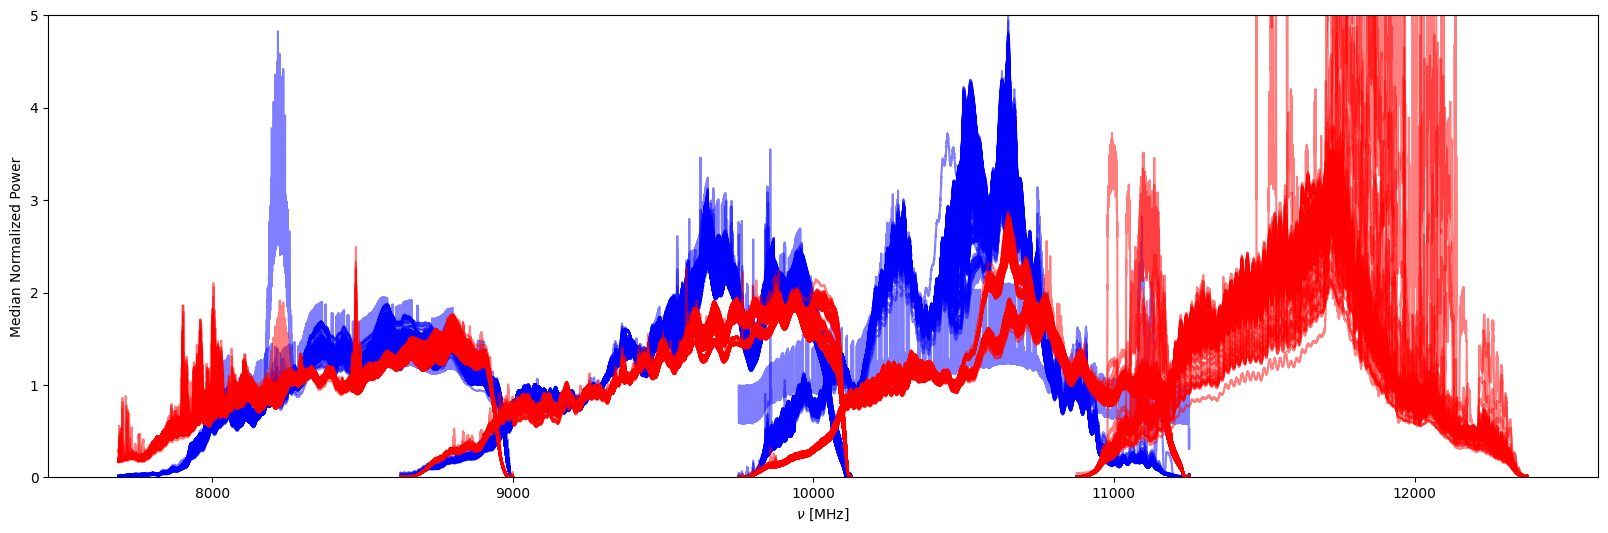

In [30]:
# Sort by times
combined = sorted(zip(times, all_data), key=lambda x: x[0])

fig, ax = plt.subplots(figsize=(20, 6))
for time, data in combined:
    ax.plot(data[0], data[1], alpha=0.5, color='red' if time > 5.18e9 else 'blue')
plt.xlabel('$\\nu$ [MHz]')
plt.ylabel('Median Normalized Power')
plt.ylim(0, 5)

# Other scans?

In [14]:
targs = ['_'.join(loc.split('/')[5].split('_')[4:-1]) for loc in locs if not any(l in loc for l in ['HIP', 'TIC'])]
len(targs)

55948

In [15]:
list(set(targs))

['',
 '3C48',
 'PSR_J1705-1906',
 'NGC4559',
 'PSR_J1932+1059',
 'And_II',
 'Galac_anti',
 'BLGCsurvey_Xband_D05',
 'GJ412A',
 'NGC3226',
 'NGC5322',
 'NGC7649',
 'GJ447',
 'BLGCsurvey_Xband_D13',
 'LS_IV-14_116',
 'IC0342',
 'SexDSph',
 'NGC6503',
 'Capella_Aa_Ab',
 'LeoII',
 'IC0010',
 'BLGCsurvey_Xband_D06',
 'Maffei1',
 'NGC4387',
 'GJ65A',
 'NGC4151',
 'BLGCsurvey_Xband_D12',
 'DIAG_FRB121102',
 'NGC5638',
 'NGC4244',
 'SexB',
 'van_Maanen_2',
 'PSR_B1133+16',
 'T08.00-08.50',
 'HD220077',
 'GJ299',
 'BLGCsurvey_Xband_D08',
 'GJ687',
 'NGC4473',
 'NGC0185',
 'OUMUAMUA',
 'DYSON7',
 'BLGCsurvey_Xband_C06',
 'GJ273',
 'BLGCsurvey_Xband_D10',
 'GJ905',
 'MESSIER42',
 'NGC6822',
 'NGC5195',
 'MESSIER87',
 'NGC584',
 'V404_Cygni',
 'PSR_B0950+08',
 'TMC1',
 'PSR_J0953+0755',
 'LeoA',
 'NGC4258',
 'LeoT',
 'SO0253',
 'NGC4551',
 'MESSIER15',
 'NGC2683',
 'GJ234',
 'Dw1',
 'HD139139',
 'GJ873',
 'And_XXIV',
 'GJ866',
 'GJ628',
 'NGC3379',
 'NGC2403',
 'UGC04879',
 'GJ71',
 'Scorpius_X-1'

In [20]:
dirs = [loc.split('/')[4] for loc in locs if 'bl' not in loc]
list(set(dirs))

['holding']

In [22]:
holding_locs = [loc for loc in locs if 'holding' in loc and 'OUMUAMUA' not in loc]
print(len(holding_locs))
holding_locs

719


['/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_81045_TMC1_0023.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80072_DIAG_PSR_J0332+5434_0019.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80655_3C48_0021.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80169_DIAG_PSR_J0332+5434_0020.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_80/holding/blc31_guppi_58105_80738_3C48_0022.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82169_DIAG_PSR_J0332+5434_0023.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82799_3C48_0025.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82100_DIAG_PSR_J0332+5434_0022.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_83291_TMC1_0027.gpuspec.0002.h5',
 '/datag/pipeline/AGBT17B_999_76/holding/blc31_guppi_58100_82882_3C48_0026.gpuspec.0002.h5',
 '/datag/p

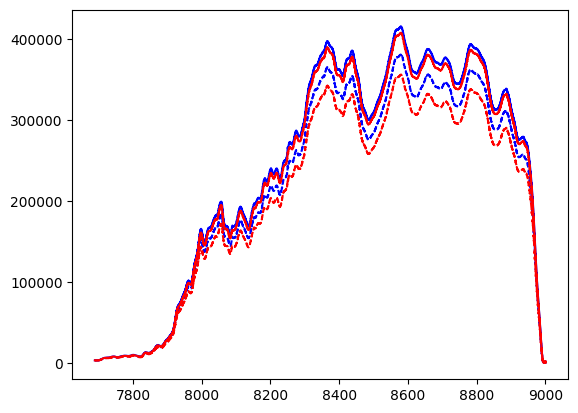

In [2]:
dir1 = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/0/3C196/59734_47623/'
dir2 = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_new/0/3C196/59734_50457/'

plt.plot(*np.load(os.path.join(dir1, 'ON.npy')), color='b')
plt.plot(*np.load(os.path.join(dir1, 'OFF.npy')), color='b', ls='--')
plt.plot(*np.load(os.path.join(dir2, 'ON.npy')), color='r')
plt.plot(*np.load(os.path.join(dir2, 'OFF.npy')), color='r', ls='--')